## Task 6: K-Nearest Neighbors (KNN) Classification

<div style="text-align: right; font-size: 20px;"><strong>SUBMITTED BY : ARJUN UNNIKRISHNAN</strong></div>



### 1. Load dataset and preprocess

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
df = pd.read_csv('Iris.csv')
X = df.iloc[:, 1:5]
y = df['Species']


### 2.Normalize Features and Split Data

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


### 3. Train KNN Classifier


In [5]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

### 4. Evaluate Model

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)


Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### 5. Visualize Decision Boundaries (2D)


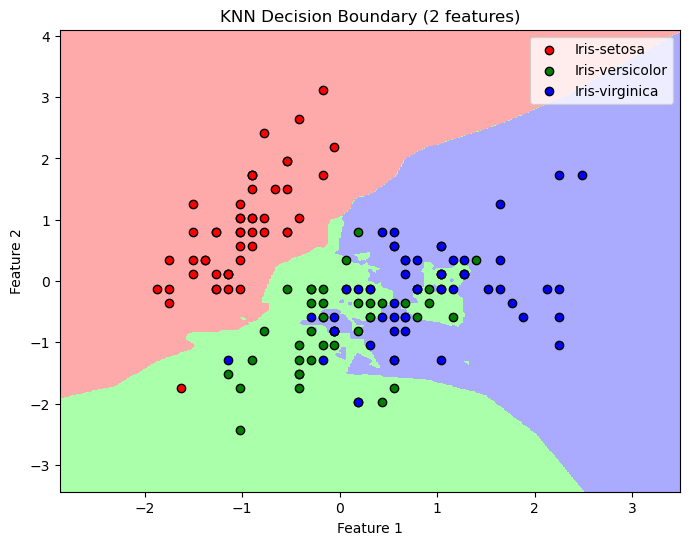

In [13]:
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
import numpy as np

X_vis = X_scaled[:, :2]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_encoded, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_vis, y_train_vis)

h = .02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']
plt.contourf(xx, yy, Z, cmap=cmap_light)

for idx in np.unique(y_encoded):
    plt.scatter(X_vis[y_encoded == idx, 0], X_vis[y_encoded == idx, 1], c=cmap_bold[idx], label=le.classes_[idx], edgecolor='k')

plt.title("KNN Decision Boundary (2 features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
